# **Regularización en Regresión Lineal: Ridge, Lasso y Elastic Net**

## **Objetivos de aprendizaje**

- Comprender el problema de sobreajuste (overfitting) y cómo la regularización lo mitiga
- Diferenciar la penalización L2 (Ridge), L1 (Lasso) y la combinación L1+L2 (Elastic Net)
- Observar cómo cada tipo de regularización modifica el vector de pesos (coeficientes) del modelo
- Construir pipelines de `scikit-learn` con escalamiento y codificación de variables categóricas

## **Dataset**

Usaremos el dataset de Kaggle [**Restaurants Revenue Prediction**](https://www.kaggle.com/datasets/mrsimple07/restaurants-revenue-prediction), que contiene información operativa de restaurantes y su ingreso mensual. El objetivo es predecir `Monthly_Revenue` a partir de:

- `Number_of_Customers`: número de clientes atendidos
- `Menu_Price`: precio promedio del menú
- `Marketing_Spend`: gasto en marketing
- `Cuisine_Type`: tipo de cocina (variable **categórica**: Japanese, Italian, American, Mexican)
- `Average_Customer_Spending`: gasto promedio por cliente
- `Promotions`: si hubo promociones activas (0/1)
- `Reviews`: número de reseñas

A diferencia del ejemplo anterior con precios de vivienda, aquí sí tenemos una variable categórica real (`Cuisine_Type`), lo que nos permite ver el `OneHotEncoder` del pipeline trabajando de verdad.

## 1. ¿Por qué regularizar?

Un modelo de regresión lineal ajusta sus pesos $\mathbf{w}$ minimizando el error cuadrático sobre el conjunto de entrenamiento (RSS - *Residual Sum of Squares*):

$$\text{RSS}(\mathbf{w}) = \sum_{i=1}^{n} \left(y^{(i)} - \hat{y}^{(i)}\right)^2$$

Cuando hay muchas variables, variables correlacionadas, o pocos datos, el modelo puede ajustar pesos muy grandes que memorizan el ruido del entrenamiento (overfitting), generalizando mal a datos nuevos.

**La regularización** agrega una penalización sobre el tamaño de los pesos a la función de costo, obligando al modelo a mantenerlos pequeños salvo que realmente ayuden a reducir el error:

| Método | Función de costo | Efecto sobre los pesos |
|---|---|---|
| **Ridge** (L2) | $\text{RSS}(\mathbf{w}) + \alpha \sum_j w_j^2$ | Encoge todos los pesos suavemente hacia 0, pero rara vez los vuelve exactamente 0 |
| **Lasso** (L1) | $\text{RSS}(\mathbf{w}) + \alpha \sum_j \lvert w_j \rvert$ | Puede llevar pesos exactamente a 0 → selección automática de características |
| **Elastic Net** (L1+L2) | $\text{RSS}(\mathbf{w}) + \alpha \left(\rho \sum_j \lvert w_j \rvert + \frac{1-\rho}{2}\sum_j w_j^2\right)$ | Combina ambos efectos según `l1_ratio` ($\rho$) |

En los tres casos, $\alpha$ controla **qué tanto** se penaliza (a mayor $\alpha$, pesos más pequeños). Como la penalización se aplica directamente sobre los valores de $w_j$, **las variables deben estar en la misma escala** antes de entrenar — de lo contrario, la penalización castigaría más a las variables con valores grandes solo por su escala, no por su importancia real.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

## 2. Carga y exploración de los datos

In [2]:
DATA_PATH = r"C:\Users\yejaramilm\OneDrive - Universidad EAFIT\CURSOS\Fundamentos de Aprendizaje Autimatico\Lecture06\data\Restaurant_revenue.csv"

restaurant_df = pd.read_csv(DATA_PATH)
restaurant_df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


In [3]:
restaurant_df.info()
print("\nValores nulos por columna:")
print(restaurant_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   str    
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 62.6 KB

Valores nulos por columna:
Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int6

In [4]:
restaurant_df.describe(include="all").round(2)

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.00,1000.00,1000.00,1000,1000.00,1000.0,1000.00,1000.00
unique,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Japanese,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,262,NaN,NaN,NaN,NaN
mean,53.27,30.22,9.96,NaN,29.48,0.5,49.84,268.72
std,26.36,11.28,5.85,NaN,11.47,0.5,29.23,103.98
min,10.00,10.01,0.00,NaN,10.04,0.0,0.00,-28.98
25%,30.00,20.40,4.69,NaN,19.60,0.0,24.00,197.10
50%,54.00,30.86,10.09,NaN,29.25,0.0,50.00,270.21
75%,74.00,39.84,14.99,NaN,39.55,1.0,76.00,343.40


In [5]:
restaurant_df["Cuisine_Type"].value_counts()

Cuisine_Type
Japanese    262
American    256
Mexican     250
Italian     232
Name: count, dtype: int64

## 3. Separación de variables y partición train/test

Solo usaremos **train** y **test**. La selección del hiperparámetro $\alpha$ (y de `l1_ratio` en Elastic Net) no necesita un conjunto de validación aparte: usaremos las versiones `*CV` de cada modelo (`RidgeCV`, `LassoCV`, `ElasticNetCV`), que internamente hacen *k-fold cross-validation* **sobre el conjunto de entrenamiento** para escoger el mejor $\alpha$. El conjunto de prueba queda completamente aislado hasta la evaluación final.

In [6]:
TARGET = "Monthly_Revenue"

X = restaurant_df.drop(columns=[TARGET])
y = restaurant_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento: (800, 7)
Tamaño de prueba: (200, 7)


## 4. Pipeline de preprocesamiento

Identificamos automáticamente las columnas numéricas y categóricas para construir un `ColumnTransformer`:

- **Numéricas** (`Number_of_Customers`, `Menu_Price`, `Marketing_Spend`, `Average_Customer_Spending`, `Promotions`, `Reviews`) → `StandardScaler` (obligatorio para que la penalización L1/L2 trate a todas las variables de forma justa).
- **Categóricas** (`Cuisine_Type`) → `OneHotEncoder`, que crea una columna binaria por cada tipo de cocina.

Al envolver todo en un `Pipeline`, el escalamiento y la codificación se ajustan (`fit`) únicamente con datos de entrenamiento y se aplican (`transform`) de forma consistente a entrenamiento y prueba.

In [7]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

Numéricas: ['Number_of_Customers', 'Menu_Price', 'Marketing_Spend', 'Average_Customer_Spending', 'Promotions', 'Reviews']
Categóricas: ['Cuisine_Type']


## 5. Modelo base: Regresión Lineal (sin regularización)

Nos sirve como punto de referencia para ver si la regularización realmente ayuda.

In [8]:
lin_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
lin_pipe.fit(X_train, y_train)

y_pred_lin = lin_pipe.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Regresión Lineal -> RMSE: {rmse_lin:,.2f} | R²: {r2_lin:.4f}")

Regresión Lineal -> RMSE: 59.67 | R²: 0.6741


## 6. Ridge Regression (penalización L2)

Ridge **encoge** todos los coeficientes hacia cero de forma proporcional, pero casi nunca los hace exactamente 0. Es útil cuando creemos que **todas las variables aportan algo** y/o cuando hay variables correlacionadas entre sí (multicolinealidad), ya que reparte el peso entre ellas en lugar de sobre-confiar en una sola.

`RidgeCV` prueba una grilla de valores de $\alpha$ usando *cross-validation* interna sobre `X_train` y se queda con el mejor.

In [9]:
alphas = np.logspace(-3, 3, 50)

ridge_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", RidgeCV(alphas=alphas, cv=5))])
ridge_pipe.fit(X_train, y_train)

y_pred_ridge = ridge_pipe.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
alpha_ridge = ridge_pipe.named_steps["model"].alpha_

print(f"Ridge (alpha óptimo = {alpha_ridge:.4f}) -> RMSE: {rmse_ridge:,.2f} | R²: {r2_ridge:.4f}")

Ridge (alpha óptimo = 8.2864) -> RMSE: 59.68 | R²: 0.6739


## 7. Lasso Regression (penalización L1)

Lasso puede llevar coeficientes **exactamente a 0**, eliminando variables poco útiles del modelo. Esto lo hace naturalmente interpretable: el vector de pesos final indica qué variables el modelo considera relevantes.

In [10]:
lasso_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", LassoCV(alphas=alphas, cv=5, max_iter=10000))])
lasso_pipe.fit(X_train, y_train)

y_pred_lasso = lasso_pipe.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
alpha_lasso = lasso_pipe.named_steps["model"].alpha_

print(f"Lasso (alpha óptimo = {alpha_lasso:.4f}) -> RMSE: {rmse_lasso:,.2f} | R²: {r2_lasso:.4f}")

Lasso (alpha óptimo = 1.1514) -> RMSE: 59.72 | R²: 0.6735


## 8. Elastic Net (L1 + L2)

Elastic Net combina ambas penalizaciones mediante `l1_ratio` ($\rho$): con $\rho=1$ es equivalente a Lasso, con $\rho=0$ es equivalente a Ridge. Es una buena opción por defecto cuando hay variables correlacionadas (donde Lasso puede elegir una al azar y descartar el resto) pero aun así queremos algo de dispersión (*sparsity*).

In [11]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

elastic_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, max_iter=10000))])
elastic_pipe.fit(X_train, y_train)

y_pred_elastic = elastic_pipe.predict(X_test)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)
alpha_elastic = elastic_pipe.named_steps["model"].alpha_
l1_ratio_elastic = elastic_pipe.named_steps["model"].l1_ratio_

print(f"Elastic Net (alpha óptimo = {alpha_elastic:.4f}, l1_ratio óptimo = {l1_ratio_elastic}) -> RMSE: {rmse_elastic:,.2f} | R²: {r2_elastic:.4f}")

Elastic Net (alpha óptimo = 1.1514, l1_ratio óptimo = 1.0) -> RMSE: 59.72 | R²: 0.6735


> **Nota:** dentro del `Pipeline`, el `StandardScaler`/`OneHotEncoder` se ajustan una sola vez sobre todo `X_train` antes de que `RidgeCV`/`LassoCV`/`ElasticNetCV` hagan su *cross-validation* interna para elegir $\alpha$. Para un ejemplo de clase esto es una simplificación razonable; en un flujo más riguroso se envolvería el `Pipeline` completo (preprocesador + modelo) dentro de un `GridSearchCV` externo para evitar cualquier fuga de información entre folds.

## 9. Comparación de métricas en el conjunto de prueba

In [12]:
results = pd.DataFrame({
    "Modelo": ["Lineal", "Ridge", "Lasso", "Elastic Net"],
    "alpha": [np.nan, alpha_ridge, alpha_lasso, alpha_elastic],
    "RMSE": [rmse_lin, rmse_ridge, rmse_lasso, rmse_elastic],
    "R2": [r2_lin, r2_ridge, r2_lasso, r2_elastic],
}).set_index("Modelo")

results.round(4)

,alpha,RMSE,R2
Modelo,,,
Lineal,NaN,59.6694,0.6741
Ridge,8.2864,59.6798,0.6739
Lasso,1.1514,59.7179,0.6735
Elastic Net,1.1514,59.7179,0.6735


## 10. Composición del vector de pesos (coeficientes)

Como todas las variables numéricas quedaron en la misma escala (media 0, desviación 1) y `Cuisine_Type` quedó codificada como columnas binarias 0/1, los coeficientes de cada modelo **son directamente comparables entre sí**: un coeficiente más grande en valor absoluto indica mayor influencia de esa variable (o categoría) sobre el ingreso predicho.

In [13]:
feature_names = lin_pipe.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Lineal": lin_pipe.named_steps["model"].coef_,
    "Ridge": ridge_pipe.named_steps["model"].coef_,
    "Lasso": lasso_pipe.named_steps["model"].coef_,
    "Elastic Net": elastic_pipe.named_steps["model"].coef_,
}, index=feature_names)

coef_df.round(2)

,Lineal,Ridge,Lasso,Elastic Net
num__Number_of_Customers,76.83,76.04,75.58,75.58
num__Menu_Price,23.68,23.46,22.64,22.64
num__Marketing_Spend,29.27,28.97,28.18,28.18
num__Average_Customer_Spending,-2.07,-2.05,-1.01,-1.01
num__Promotions,-2.24,-2.20,-1.07,-1.07
num__Reviews,-0.45,-0.44,-0.00,-0.00
cat__Cuisine_Type_American,-0.55,-0.49,-0.00,-0.00
cat__Cuisine_Type_Italian,-1.86,-1.80,-0.00,-0.00
cat__Cuisine_Type_Japanese,-0.10,-0.06,0.00,0.00
cat__Cuisine_Type_Mexican,2.50,2.35,0.00,0.00


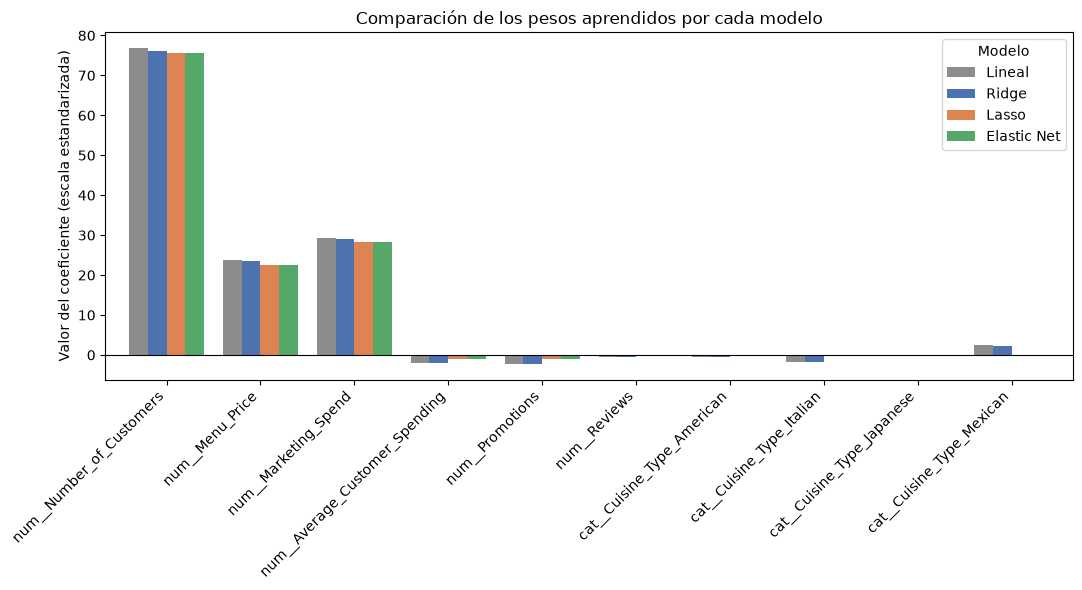

In [14]:
colors = {"Lineal": "#8C8C8C", "Ridge": "#4C72B0", "Lasso": "#DD8452", "Elastic Net": "#55A868"}

ax = coef_df.plot(kind="bar", figsize=(11, 6), color=[colors[c] for c in coef_df.columns], width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Valor del coeficiente (escala estandarizada)")
ax.set_xlabel("")
ax.set_title("Comparación de los pesos aprendidos por cada modelo")
ax.legend(title="Modelo")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### ¿Cuántos coeficientes "apaga" cada modelo?

Contamos cuántos pesos quedaron prácticamente en cero (`|w| > 1e-3`) para visualizar la dispersión (*sparsity*) de cada vector de pesos. Se espera que Lasso y Elastic Net (con `l1_ratio` alto) reduzcan más variables que Ridge o la regresión lineal simple.

Número de coeficientes distintos de cero por modelo (de 10 variables):
Lineal         10
Ridge          10
Lasso           5
Elastic Net     5
dtype: int64


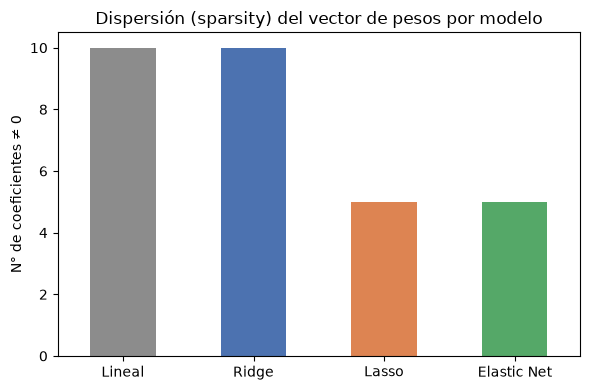

In [15]:
threshold = 1e-3
nonzero_counts = (coef_df.abs() > threshold).sum()
print("Número de coeficientes distintos de cero por modelo (de", len(coef_df), "variables):")
print(nonzero_counts)

ax = nonzero_counts.plot(kind="bar", color=[colors[c] for c in nonzero_counts.index], figsize=(6, 4))
ax.set_ylabel("N° de coeficientes ≠ 0")
ax.set_xlabel("")
ax.set_title("Dispersión (sparsity) del vector de pesos por modelo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Trayectoria de los coeficientes según $\alpha$ (regularization path)

Para **ver claramente el efecto de la regularización sobre el vector de pesos**, forzamos manualmente un barrido de valores de $\alpha$ (cada vez más grandes) y graficamos cómo evoluciona cada coeficiente. Esta es la visualización clásica para comparar Ridge y Lasso:

- En **Ridge**, todos los coeficientes se encogen de forma suave y continua hacia 0, pero ninguno la toca exactamente.
- En **Lasso**, los coeficientes van llegando a exactamente 0 en distintos valores de $\alpha$ — las líneas se "apagan" una por una a medida que $\alpha$ crece.

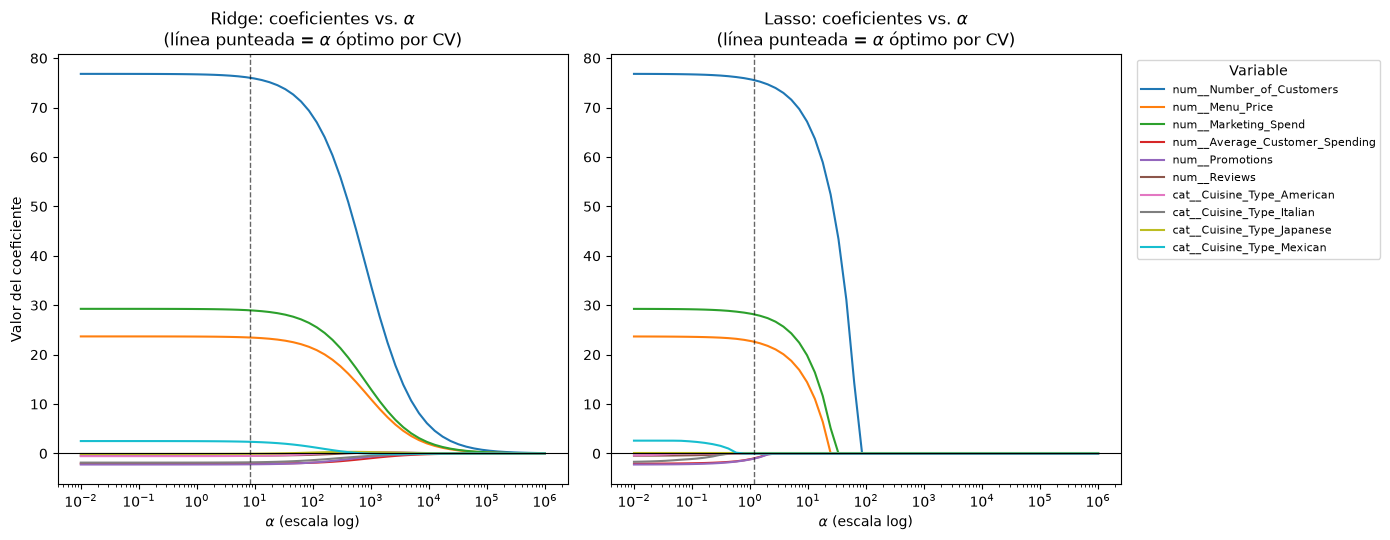

In [16]:
from sklearn.linear_model import Ridge, Lasso

# Reutilizamos el mismo preprocesador (ya ajustado) para trabajar directamente sobre datos escalados/codificados
X_train_proc = lin_pipe.named_steps["preprocessor"].transform(X_train)

path_alphas = np.logspace(-2, 6, 60)

ridge_coef_path = np.array([Ridge(alpha=a).fit(X_train_proc, y_train).coef_ for a in path_alphas])
lasso_coef_path = np.array([Lasso(alpha=a, max_iter=20000).fit(X_train_proc, y_train).coef_ for a in path_alphas])

feature_colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)

for i, name in enumerate(feature_names):
    axes[0].plot(path_alphas, ridge_coef_path[:, i], color=feature_colors[i % 10], label=name)
    axes[1].plot(path_alphas, lasso_coef_path[:, i], color=feature_colors[i % 10], label=name)

for ax, title, alpha_opt in zip(axes, ["Ridge", "Lasso"], [alpha_ridge, alpha_lasso]):
    ax.set_xscale("log")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(alpha_opt, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_xlabel(r"$\alpha$ (escala log)")
    ax.set_title(f"{title}: coeficientes vs. $\\alpha$\n(línea punteada = $\\alpha$ óptimo por CV)")

axes[0].set_ylabel("Valor del coeficiente")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Variable")
plt.tight_layout()
plt.show()

## 12. Conclusiones

- **Ridge (L2)** encoge todos los pesos de forma suave, pero conserva todas las variables en el modelo. Es buena opción cuando muchas variables aportan algo de información y hay colinealidad entre ellas.
- **Lasso (L1)** puede anular por completo el peso de algunas variables (o de algunas categorías de `Cuisine_Type`), actuando como un mecanismo automático de selección de características. Es útil cuando se sospecha que solo unas pocas variables son realmente relevantes.
- **Elastic Net** combina ambos comportamientos mediante `l1_ratio`, siendo un punto intermedio razonable cuando no se sabe de antemano si conviene la dispersión de Lasso o la estabilidad de Ridge, especialmente con variables correlacionadas.
- El hiperparámetro $\alpha$ controla el equilibrio sesgo-varianza: valores muy altos sub-ajustan el modelo (demasiada penalización), valores muy bajos se acercan a la regresión lineal sin regularizar (riesgo de sobreajuste). El gráfico de la sección 11 muestra ese barrido completo.
- Comparar `RMSE` y `R²` en el conjunto de **prueba** (nunca usado durante el entrenamiento ni la selección de $\alpha$) es lo que permite juzgar si la regularización realmente mejoró la capacidad de generalización del modelo.
- A diferencia del ejemplo de precios de vivienda, aquí sí tenemos una variable categórica (`Cuisine_Type`) codificada con `OneHotEncoder`: vale la pena comparar en la tabla de coeficientes si alguna categoría de cocina termina con peso cercano a 0 en Lasso/Elastic Net, es decir, si el tipo de cocina en sí no aporta información una vez que ya conocemos el resto de variables del restaurante.

**Para explorar en clase:** cambiar el rango de `alphas`, usar `drop="first"` en el `OneHotEncoder` para evitar la categoría de referencia redundante, o comparar este dataset con el de precios de vivienda para discutir por qué la regularización influye más o menos según qué tan ruidosa/correlacionada sea cada fuente de datos.